### 1. Connect to SQLite Sakila database
I connected to the SQLite Sakila database using the `sqlite3` library.  
This allows us to query the database and work with its tables inside Pandas DataFrames.

In [1]:
import os
import sqlite3
import pandas as pd

# Correct path to your Sakila database
DB_PATH = "/Users/wangxiaoxiao/Desktop/1st/sqlite-sakila.db"

# Check that the file exists
assert os.path.exists(DB_PATH), f"DB not found at {DB_PATH}"

# Connect to the database
conn = sqlite3.connect(DB_PATH)
print("Connection successful:", DB_PATH)


Connection successful: /Users/wangxiaoxiao/Desktop/1st/sqlite-sakila.db


### 2. Query to return film, rental, and payment information
I wrote a SQL query that joins the `film`, `inventory`, `rental`, and `payment` tables.  
This produces a dataset with multiple rows per film, where each row corresponds to one rental and its associated payment.

In [2]:
query = """
SELECT f.film_id,
       f.title,
       r.rental_id,
       r.rental_date,
       p.payment_id,
       p.amount,
       p.payment_date
FROM film f
JOIN inventory i ON f.film_id = i.film_id
JOIN rental r ON i.inventory_id = r.inventory_id
JOIN payment p ON r.rental_id = p.rental_id;
"""

film_rental_payment_df = pd.read_sql_query(query, conn)
print("Film–Rental–Payment DataFrame shape:", film_rental_payment_df.shape)
film_rental_payment_df.head()

Film–Rental–Payment DataFrame shape: (16044, 7)


,film_id,title,rental_id,rental_date,payment_id,amount,payment_date
0,663,PATIENT SISTER,76,2005-05-25 11:30:37.000,1,2.99,2005-05-25 11:30:37.000
1,875,TALENTED HOMICIDE,573,2005-05-28 10:35:23.000,2,0.99,2005-05-28 10:35:23.000
2,611,MUSKETEERS WAIT,1185,2005-06-15 00:54:12.000,3,5.99,2005-06-15 00:54:12.000
3,228,DETECTIVE VISION,1422,2005-06-15 18:02:53.000,4,0.99,2005-06-15 18:02:53.000
4,308,FERRIS MOTHER,1476,2005-06-15 21:08:46.000,5,9.99,2005-06-15 21:08:46.000


### 3. Create a DataFrame from the customer table
I created a DataFrame from the `customer` table by selecting all of its columns.  
This DataFrame includes details such as `customer_id`, `store_id`, `first_name`, `last_name`, `email`, and activity status.

In [3]:
customer_df = pd.read_sql_query("SELECT * FROM customer;", conn)
print("Customer DataFrame shape:", customer_df.shape)
customer_df.head()

Customer DataFrame shape: (599, 9)


,customer_id,store_id,first_name,last_name,email,address_id,active,create_date,last_update
0,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36
1,2,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36
2,3,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36
3,4,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36
4,5,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36


### 2.1 — Create a full customer name column
I created a new column `customer_name` in the `customer_df` DataFrame by concatenating `first_name` and `last_name`.  
This provides a single field for the customer's full name.


In [4]:
customer_df = customer_df.copy()
customer_df["customer_name"] = customer_df["first_name"].astype(str) + " " + customer_df["last_name"].astype(str)

customer_df[["customer_id", "first_name", "last_name", "customer_name"]].head()


,customer_id,first_name,last_name,customer_name
0,1,MARY,SMITH,MARY SMITH
1,2,PATRICIA,JOHNSON,PATRICIA JOHNSON
2,3,LINDA,WILLIAMS,LINDA WILLIAMS
3,4,BARBARA,JONES,BARBARA JONES
4,5,ELIZABETH,BROWN,ELIZABETH BROWN


### 2.2 — Remove inactive customers (robust to `active` dtype)
I normalized the `active` column so it works whether values are numeric (1/0), strings ("1"/"0"), or booleans (True/False).  
Then I filtered to keep only active customers and stored the result in `customer_active_df`.

In [5]:
import pandas as pd
import numpy as np

# Start from the full customer_df
assert "customer_df" in globals(), "Run Section 1 first to create `customer_df`."

def _is_active(val):
    s = str(val).strip().lower()
    if s in {"1", "true", "t", "yes", "y"}:
        return True
    try:
        return float(val) == 1.0
    except Exception:
        return bool(val)

# Build a robust boolean flag
active_flag = customer_df["active"].apply(_is_active).astype(bool)

# Filter to active-only
customer_active_df = customer_df.loc[active_flag].copy()
print("Original rows:", len(customer_df), "| Active rows:", len(customer_active_df))

# Quick sanity check
customer_active_df.head()

Original rows: 599 | Active rows: 584


,customer_id,store_id,first_name,last_name,email,address_id,active,create_date,last_update,customer_name
0,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,MARY SMITH
1,2,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,PATRICIA JOHNSON
2,3,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,LINDA WILLIAMS
3,4,2,BARBARA,JONES,BARBARA.JONES@sakilacustomer.org,8,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,BARBARA JONES
4,5,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,ELIZABETH BROWN


### 2.3 — Replace emails for even-numbered stores using `apply` (position-safe)
Following the hint, I used `apply(axis=1)` to compute a strict boolean mask for rows whose `store_id` is even.  
To avoid any duplicate-name ambiguity, I located the first `email` column **by position** and assigned the replacement email only to those rows.

In [6]:
import numpy as np

# Ensure we have the active-only DataFrame
assert "customer_active_df" in globals(), "Run Section 2.2 first."

# Locate the first 'email' column by position (robust even if duplicate names exist)
email_positions = np.flatnonzero(customer_active_df.columns.values == "email")
assert len(email_positions) >= 1, "No 'email' column found."
email_idx = int(email_positions[0])

# Build a strict boolean mask with apply (hint-compliant)
even_mask = customer_active_df.apply(
    lambda row: (pd.to_numeric(row["store_id"], errors="coerce") % 2 == 0), axis=1
).fillna(False).astype(bool)

# Assign replacement email by column position (scalar write avoids shape/key errors)
customer_active_df.iloc[even_mask.values, email_idx] = "joe.person@wustl.edu"

# Report how many rows changed and show a sample with all columns
print("Rows changed:", int(even_mask.sum()))
customer_active_df.head(10)

Rows changed: 266


,customer_id,store_id,first_name,last_name,email,address_id,active,create_date,last_update,customer_name
0,1,1,MARY,SMITH,MARY.SMITH@sakilacustomer.org,5,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,MARY SMITH
1,2,1,PATRICIA,JOHNSON,PATRICIA.JOHNSON@sakilacustomer.org,6,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,PATRICIA JOHNSON
2,3,1,LINDA,WILLIAMS,LINDA.WILLIAMS@sakilacustomer.org,7,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,LINDA WILLIAMS
3,4,2,BARBARA,JONES,joe.person@wustl.edu,8,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,BARBARA JONES
4,5,1,ELIZABETH,BROWN,ELIZABETH.BROWN@sakilacustomer.org,9,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,ELIZABETH BROWN
5,6,2,JENNIFER,DAVIS,joe.person@wustl.edu,10,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,JENNIFER DAVIS
6,7,1,MARIA,MILLER,MARIA.MILLER@sakilacustomer.org,11,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,MARIA MILLER
7,8,2,SUSAN,WILSON,joe.person@wustl.edu,12,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,SUSAN WILSON
8,9,2,MARGARET,MOORE,joe.person@wustl.edu,13,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,MARGARET MOORE
9,10,1,DOROTHY,TAYLOR,DOROTHY.TAYLOR@sakilacustomer.org,14,1,2006-02-14 22:04:36.000,2021-03-06 15:53:36,DOROTHY TAYLOR


### 3.1 — Counts of films by rating and category (Action, Animation, Comedy)
I computed counts of films by `rating × category` using SQL (restricted to Action, Animation, and Comedy).  
Then I pivoted the result so that rows are ratings and columns are categories.


In [7]:
# SQL counts: rating × category for Action/Animation/Comedy only
sql_counts = """
SELECT f.rating,
       c.name AS category,
       COUNT(*) AS n
FROM film AS f
JOIN film_category AS fc ON fc.film_id = f.film_id
JOIN category AS c       ON c.category_id = fc.category_id
WHERE c.name IN ('Action', 'Animation', 'Comedy')
GROUP BY f.rating, c.name
ORDER BY f.rating, c.name;
"""
counts_df = pd.read_sql_query(sql_counts, conn)

# Pivot to rating (rows) × category (columns)
counts_pivot = (
    counts_df
    .pivot(index="rating", columns="category", values="n")
    .fillna(0)
    .astype(int)
    .sort_index()
)

print("Counts table (rating × category):")
counts_pivot


Counts table (rating × category):


category,Action,Animation,Comedy
rating,,,
G,18,13,11
NC-17,12,15,11
PG,9,11,16
PG-13,11,19,12
R,14,8,8


### 3.2 — Identify the most frequent rating–category combination
I identified the single rating–category cell with the maximum count of films.


In [8]:
# Flatten the pivot table to find the max cell
stacked = counts_pivot.stack()  # MultiIndex: (rating, category) -> count
max_idx = stacked.idxmax()
max_val = int(stacked.max())

print("Most frequent combination:")
print(f"Rating: {max_idx[0]} | Category: {max_idx[1]} | Count: {max_val}")


Most frequent combination:
Rating: PG-13 | Category: Animation | Count: 19


### 3.3 — Row percentages within each rating
I computed row percentages so that, within each rating, the shares across Action, Animation, and Comedy sum to 1.  
These percentages are added as additional columns with a `_pct` suffix.


In [9]:
# Row-wise percentages within each rating
row_sums = counts_pivot.sum(axis=1).replace(0, pd.NA)
pct = (counts_pivot.div(row_sums, axis=0)).round(4)

# Combine counts and percentages into one DataFrame
result_with_pct = counts_pivot.copy()
for col in ["Action", "Animation", "Comedy"]:
    result_with_pct[f"{col}_pct"] = pct[col]

print("Counts + percentages (within rating):")
result_with_pct


Counts + percentages (within rating):


category,Action,Animation,Comedy,Action_pct,Animation_pct,Comedy_pct
rating,,,,,,
G,18,13,11,0.4286,0.3095,0.2619
NC-17,12,15,11,0.3158,0.3947,0.2895
PG,9,11,16,0.2500,0.3056,0.4444
PG-13,11,19,12,0.2619,0.4524,0.2857
R,14,8,8,0.4667,0.2667,0.2667


### 3.3 (answer) — Which category dominates PG-13?
From the row percentages for PG-13, I selected the category with the largest proportion.


In [10]:
if "PG-13" in pct.index:
    pg13_row = pct.loc["PG-13"]
    top_category_pg13 = pg13_row.idxmax()
    top_share_pg13 = float(pg13_row.max())
    print(f"PG-13 highest proportion: {top_category_pg13} ({top_share_pg13:.3f})")
else:
    print("No PG-13 rating found in the data.")


PG-13 highest proportion: Animation (0.452)


### 3.3 (plot) — Plot of PG-13 category percentages
I plotted the three category percentages for PG-13 as a bar chart.  
The y-axis shows proportions (0–1).


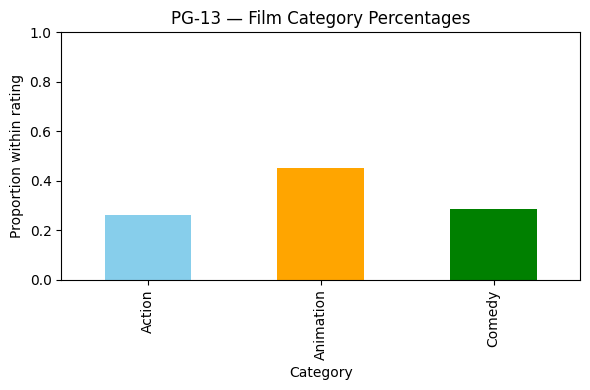

In [11]:
import matplotlib.pyplot as plt

if "PG-13" in pct.index:
    pg13_pct = pct.loc["PG-13", ["Action", "Animation", "Comedy"]]

    plt.figure(figsize=(6, 4))
    pg13_pct.plot(kind="bar", color=["skyblue", "orange", "green"])
    plt.title("PG-13 — Film Category Percentages")
    plt.ylabel("Proportion within rating")
    plt.xlabel("Category")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("No PG-13 rating found to plot.")


### 4.1 — Build film-level revenue
I define **film revenue** for each film as:

> `revenue_per_film = (number of rentals of that film) × (film.rental_rate)`

Below I join `film → inventory → rental` to count how many times each film was rented, then multiply by `rental_rate`. The result is stored in `film_rev_df`.


In [12]:
import pandas as pd

# Ensure the DB connection from Section 1 exists
assert 'conn' in globals(), "Please run Section 1 (database connection) first."

# Count rentals per film and collect rental_rate and rating
sql_counts_per_film = """
SELECT
    f.film_id,
    f.title,
    f.rating,
    f.rental_rate,
    COUNT(r.rental_id) AS rentals_count
FROM film AS f
JOIN inventory AS i ON i.film_id = f.film_id
JOIN rental   AS r ON r.inventory_id = i.inventory_id
GROUP BY f.film_id, f.title, f.rating, f.rental_rate
ORDER BY f.film_id;
"""

film_rev_df = pd.read_sql_query(sql_counts_per_film, conn)

# Compute revenue per film
film_rev_df["revenue_per_film"] = film_rev_df["rentals_count"] * film_rev_df["rental_rate"]

# Quick preview
film_rev_df[["film_id", "title", "rating", "rental_rate", "rentals_count", "revenue_per_film"]].head()


,film_id,title,rating,rental_rate,rentals_count,revenue_per_film
0,1,ACADEMY DINOSAUR,PG,0.99,23,22.77
1,2,ACE GOLDFINGER,G,4.99,7,34.93
2,3,ADAPTATION HOLES,NC-17,2.99,12,35.88
3,4,AFFAIR PREJUDICE,G,2.99,23,68.77
4,5,AFRICAN EGG,G,2.99,12,35.88


The distribution of film revenue is **right-skewed** (skewness ≈ 0.920), indicating a longer right tail – a few films earned significantly more than most others. The **excess kurtosis** is ≈ 0.167, very close to 0, which means the tail heaviness is near that of a normal distribution (only slightly more outliers than a perfect normal curve).


### 4.2 — Distribution, skewness, and kurtosis of film revenue
I plotted the histogram of `revenue_per_film` to visualize its distribution.  
Then I computed **skewness** and **excess kurtosis** to describe the shape (tail direction and tail heaviness).


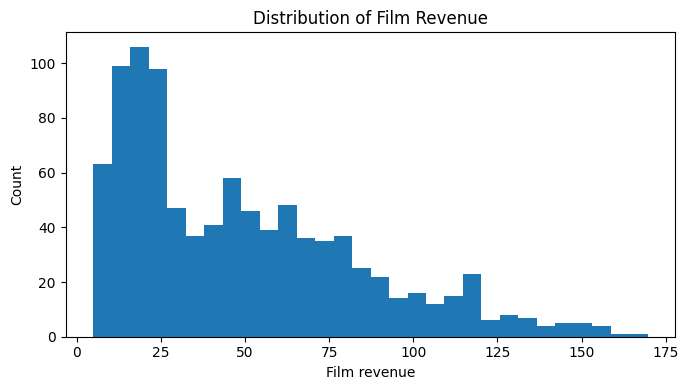

Skewness: 0.920
Excess Kurtosis: 0.167


In [13]:
import matplotlib.pyplot as plt

# Plot histogram
plt.figure(figsize=(7, 4))
film_rev_df["revenue_per_film"].plot(kind="hist", bins=30)
plt.title("Distribution of Film Revenue")
plt.xlabel("Film revenue")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Compute skewness and excess kurtosis
skew_val = film_rev_df["revenue_per_film"].skew()
kurt_val = film_rev_df["revenue_per_film"].kurtosis()  # excess kurtosis by default

print(f"Skewness: {skew_val:.3f}")
print(f"Excess Kurtosis: {kurt_val:.3f}")


### 4.3 — Film revenue by rating (centrality and dispersion)
For each rating, I compute:
- Centrality: mean, median, mode
- Dispersion: variance, standard deviation, and IQR


In [14]:
import numpy as np

def iqr(s: pd.Series) -> float:
    return float(s.quantile(0.75) - s.quantile(0.25))

grp = film_rev_df.groupby("rating")["revenue_per_film"]

stats_df = pd.DataFrame({
    "mean": grp.mean(),
    "median": grp.median(),
    "mode": grp.apply(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    "variance": grp.var(ddof=1),
    "std": grp.std(ddof=1),
    "IQR": grp.apply(iqr)
}).sort_index()

print("Revenue by rating — centrality and dispersion:")
stats_df


Revenue by rating — centrality and dispersion:


,mean,median,mode,variance,std,IQR
rating,,,,,,
G,46.054211,34.93,79.84,1118.796334,33.448413,51.465
NC-17,49.812228,38.87,15.84,1506.094881,38.808438,51.050
PG,51.726120,44.91,20.79,1218.167710,34.902259,47.415
PG-13,50.690845,44.85,44.91,1159.364479,34.049442,53.070
R,47.678254,39.92,13.86,1109.136593,33.303702,47.980


### 4.3 (answers)
- **Highest average revenue**: PG (mean ≈ 51.73)  
- **Lowest average revenue**: G (mean ≈ 46.05)  
- **Most variable rating**: 
  - by standard deviation → NC-17 (std ≈ 38.81)  
  - by IQR → PG-13 (IQR ≈ 53.07)  


### 4.4 — Visualize film revenue by rating
I use a boxplot of `revenue_per_film` grouped by `rating` to compare spread, center, and potential outliers across ratings.  
This plot complements the table by showing skew and dispersion visually.


<Figure size 800x500 with 0 Axes>

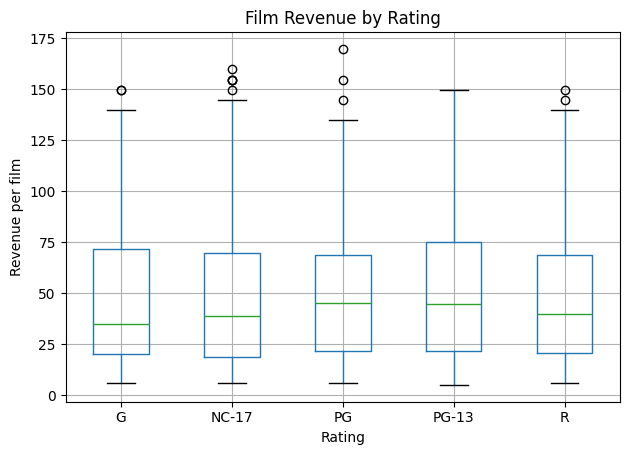

In [15]:
import matplotlib.pyplot as plt

# Ensure film_rev_df exists from 4.1
assert "film_rev_df" in globals(), "Please run Section 4.1 first to build `film_rev_df`."

plt.figure(figsize=(8, 5))
film_rev_df.boxplot(column="revenue_per_film", by="rating")
plt.title("Film Revenue by Rating")
plt.suptitle("")  # remove the automatic 'Boxplot grouped by rating' title
plt.xlabel("Rating")
plt.ylabel("Revenue per film")
plt.tight_layout()
plt.show()


## Section 5 — Sampling from a Normal Distribution


### 5.1 — Generate normal samples
I generate four independent samples from a normal distribution $N(15, 2^2)$:

- `x1`: n = 5  
- `x2`: n = 25  
- `x3`: n = 125  
- `x4`: n = 625


In [29]:
import numpy as np

np.random.seed(200)  # reproducibility
x1 = np.random.normal(15, 2, 5)
x2 = np.random.normal(15, 2, 25)
x3 = np.random.normal(15, 2, 125)
x4 = np.random.normal(15, 2, 625)

print("Sample sizes:", len(x1), len(x2), len(x3), len(x4))


Sample sizes: 5 25 125 625


### 5.2 — Histograms of samples
I plot histograms with KDE for each sample (`x1`–`x4`) to compare how closely each resembles the true normal distribution as n increases.


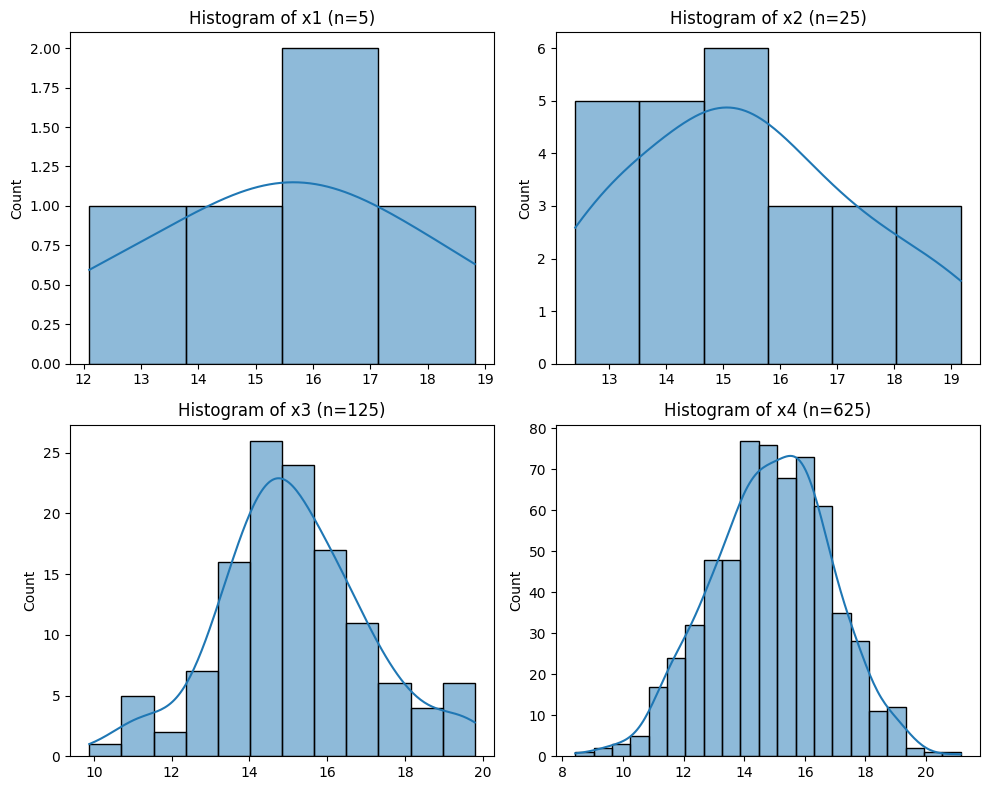

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (data, name) in zip(axes.flat, [(x1,'x1'),(x2,'x2'),(x3,'x3'),(x4,'x4')]):
    sns.histplot(data, kde=True, ax=ax)
    ax.set_title(f"Histogram of {name} (n={len(data)})")
plt.tight_layout()
plt.show()


### 5.3 — Sample statistics
For each sample I compute:
- mean  
- standard deviation (SD)  
- standard error (SE = SD / sqrt(n))  


In [31]:
import math

for i, data in enumerate([x1, x2, x3, x4], start=1):
    mean = data.mean()
    sd = data.std(ddof=1)
    se = sd / math.sqrt(len(data))
    print(f"x{i} (n={len(data)}) — mean: {mean:.2f}, std: {sd:.2f}, SE: {se:.2f}")


x1 (n=5) — mean: 15.51, std: 2.47, SE: 1.11
x2 (n=25) — mean: 15.38, std: 2.00, SE: 0.40
x3 (n=125) — mean: 15.13, std: 1.93, SE: 0.17
x4 (n=625) — mean: 14.89, std: 1.95, SE: 0.08


### 5.4 — Comparison and discussion
All samples were drawn from a $N(15, 2^2)$ distribution (true mean = 15, true SD = 2).

- **x1 (n=5)**: The mean and SD can deviate quite a bit from the population values because of the very small sample. The SE is large, so the sample mean is unreliable.
- **x2 (n=25)**: The mean and SD are closer to the true values. The SE is smaller, showing more stability.
- **x3 (n=125)**: The mean is very close to 15, SD is close to 2, and SE is small. The histogram resembles the true normal shape.
- **x4 (n=625)**: The mean and SD are almost identical to the population parameters. SE is very small, confirming the law of large numbers.

**Overall:** As sample size increases, sample means cluster closer to the true mean, the SD stabilizes near 2, and SE decreases. Larger samples provide more reliable estimates and distributions that look more like the population.


### 6.1 — Load the Excel data and preview
I load the Excel file **GnT.xlsx** into a DataFrame and show the first few rows to understand the structure before cleaning.


In [19]:
import os
import pandas as pd

# --- Option A: set the path directly if you know it ---
# GNTPATH = "/path/to/GnT.xlsx"

# --- Option B: try to auto-find the file by name in common locations ---
possible_dirs = [
    os.getcwd(),
    os.path.expanduser("~/Desktop"),
    os.path.expanduser("~/Desktop/1st"),
]
GNTPATH = None
for base in possible_dirs:
    if not os.path.isdir(base):
        continue
    for root, _, files in os.walk(base):
        if "GnT.xlsx" in files:
            GNTPATH = os.path.join(root, "GnT.xlsx")
            break
    if GNTPATH:
        break

assert GNTPATH is not None, "Could not find GnT.xlsx. Set GNTPATH manually."

print("Using:", GNTPATH)

# Read sheet names and pick the first one by default
xls = pd.ExcelFile(GNTPATH)
print("Sheets:", xls.sheet_names)

# If your assignment specifies a particular sheet, replace xls.sheet_names[0] with that name.
sheet_to_read = xls.sheet_names[0]
gnt_df = pd.read_excel(GNTPATH, sheet_name=sheet_to_read)

print("Shape:", gnt_df.shape)
gnt_df.head(10)


Using: /Users/wangxiaoxiao/Desktop/1st/GnT.xlsx
Sheets: ['Form Responses 1']
Shape: (117, 12)


,Timestamp,Entering Grade Level,District,Birth Month,OLSAT Verbal Score,OLSAT Verbal Percentile,NNAT Non Verbal Raw Score,NNAT Non Verbal Percentile,Overall Score,School Preferences,School Assigned,Will you enroll there?
0,2017-04-08 06:44:00.672,1,6.0,September,28,99,45,99,99,"NEST+m, TAG, Anderson, Q300",NEST,YES
1,2017-04-07 10:40:44.772,K,NaN,August,25,99,39,99,99,"Anderson, NEST+m",NaN,Maybe
2,2017-04-07 10:41:55.730,1,NaN,March,27,96,42,99,98,NaN,NaN,Maybe
3,2017-04-07 10:43:30.543,K,NaN,September,23,97,40,99,98,NaN,NaN,NaN
4,2017-04-10 10:18:34.314,K,22.0,April,25,98,38,99,99,Brooklyn School of Inquiry,Currently - local Brooklyn dual language,Maybe
5,2017-04-07 11:03:21.121,K,NaN,May,24,97,36,98,98,NaN,NaN,NaN
6,2017-04-07 11:15:27.586,K,NaN,February,26,99,42,99,99,Anderson NEST TAG Q300,NaN,NaN
7,2017-04-07 11:26:15.605,K,NaN,October,24,99,42,99,99,"Nest+M, Anderson",NaN,Yes
8,2017-04-07 11:31:41.125,1,NaN,March,23,81,42,99,95,NaN,NaN,NaN
9,2017-04-07 11:32:51.636,2,NaN,April,29,99,44,99,99,Any citywide or district 3 school,NaN,Yes


### 6.2 — Inspect dtypes and outline expected types
Below I list the current `dtypes` and a brief expectation for each column:

- `Timestamp` → datetime
- `Entering Grade Level` → categorical/string (e.g., "K", "1", "2")
- `District` → numeric integer (may include missing)
- `Birth Month` → categorical/string (e.g., "January", "February", …)
- `OLSAT Verbal Score` → numeric
- `OLSAT Verbal Percentile` → numeric (0–100)
- `NNAT Non Verbal Raw Score` → numeric
- `NNAT Non Verbal Percentile` → numeric (0–100)
- `Overall Score` → numeric (0–100)
- `School Preferences` → free-text string
- `School Assigned` → categorical/string (may be missing)
- `Will you enroll there?` → categorical/string (Yes/No/Maybe, with possible variants)

I first print the current dtypes and a few value checks to see what needs cleaning.


In [20]:
# Show raw dtypes
print("Current dtypes:\n", gnt_df.dtypes, "\n")

# Quick value audits that often reveal typing problems
checks = {
    "grade_sample": gnt_df["Entering Grade Level"].value_counts(dropna=False).head(10),
    "district_sample": gnt_df["District"].head(10).to_list(),
    "birth_month_sample": gnt_df["Birth Month"].value_counts(dropna=False).head(12),
    "will_enroll_sample": gnt_df["Will you enroll there?"].value_counts(dropna=False),
}

for name, obj in checks.items():
    print(f"\n--- {name} ---")
    print(obj)

# Simple numeric coercion probes (do not modify the data yet)
numeric_probe_cols = [
    "District",
    "OLSAT Verbal Score",
    "OLSAT Verbal Percentile",
    "NNAT Non Verbal Raw Score",
    "NNAT Non Verbal Percentile",
    "Overall Score",
]
probe = (
    gnt_df[numeric_probe_cols]
    .apply(lambda s: pd.to_numeric(s, errors="coerce"))
    .isna()
    .sum()
)
print("\nPotential non-numeric entries (count of NaNs after coercion):")
print(probe)


Current dtypes:
 Timestamp                     datetime64[ns]
Entering Grade Level                  object
District                             float64
Birth Month                           object
OLSAT Verbal Score                    object
OLSAT Verbal Percentile               object
NNAT Non Verbal Raw Score             object
NNAT Non Verbal Percentile             int64
Overall Score                          int64
School Preferences                    object
School Assigned                       object
Will you enroll there?                object
dtype: object 


--- grade_sample ---
Entering Grade Level
K    77
1    28
2    10
3     2
Name: count, dtype: int64

--- district_sample ---
[6.0, nan, nan, nan, 22.0, nan, nan, nan, nan, nan]

--- birth_month_sample ---
Birth Month
January      18
March        14
May          13
April        12
February     11
December     11
July         11
October       7
November      7
August        6
September     4
June          3
Name: count, dtyp

### 6.3 — Clean and standardize columns
I standardize column types and values:

- `District` → numeric nullable integer (`Int64`)
- `Birth Month` → ordered categorical (January … December)
- `Entering Grade Level` → categorical strings (`K`, `1`, `2`, `3`)
- OLSAT/NNAT/Overall numeric fields → coerced to numeric (`errors='coerce'`)
- `Will you enroll there?` → normalized to `Yes` / `No` / `Maybe` (others → NaN)

I also strip leading/trailing spaces for string columns.


In [21]:
import numpy as np
import pandas as pd

# Work on a copy to keep original intact if needed
gnt_clean = gnt_df.copy()

# 0) Strip whitespace for all object columns
obj_cols = gnt_clean.select_dtypes(include=["object"]).columns
for c in obj_cols:
    gnt_clean[c] = gnt_clean[c].astype(str).str.strip().replace({"nan": np.nan})

# 1) District → numeric nullable integer
gnt_clean["District"] = pd.to_numeric(gnt_clean["District"], errors="coerce").astype("Int64")

# 2) Birth Month → ordered categorical (Jan..Dec)
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
# Normalize month capitalization (in case of variants)
gnt_clean["Birth Month"] = (
    gnt_clean["Birth Month"]
    .str.title()
    .where(gnt_clean["Birth Month"].notna(), other=np.nan)
)
gnt_clean["Birth Month"] = pd.Categorical(
    gnt_clean["Birth Month"], categories=month_order, ordered=True
)

# 3) Entering Grade Level → categorical string in {K, 1, 2, 3}
def normalize_grade(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    if s in {"K", "KINDERGARTEN"}:
        return "K"
    if s in {"1","2","3"}:
        return s
    # any other unexpected code → keep original uppercase
    return s

gnt_clean["Entering Grade Level"] = gnt_clean["Entering Grade Level"].apply(normalize_grade)
gnt_clean["Entering Grade Level"] = pd.Categorical(
    gnt_clean["Entering Grade Level"], categories=["K","1","2","3"], ordered=True
)

# 4) Force numeric for OLSAT/NNAT/Overall columns (coerce errors to NaN)
numeric_cols = [
    "OLSAT Verbal Score",
    "OLSAT Verbal Percentile",
    "NNAT Non Verbal Raw Score",
    "NNAT Non Verbal Percentile",
    "Overall Score",
]
before_na = gnt_clean[numeric_cols].isna().sum()
for col in numeric_cols:
    gnt_clean[col] = pd.to_numeric(gnt_clean[col], errors="coerce")
after_na = gnt_clean[numeric_cols].isna().sum()

# 5) Normalize 'Will you enroll there?' → Yes/No/Maybe
def norm_enroll(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"yes","y"}:
        return "Yes"
    if s in {"no","n"}:
        return "No"
    if s in {"maybe","m"}:
        return "Maybe"
    return np.nan  # anything else → missing

gnt_clean["Will you enroll there?"] = gnt_clean["Will you enroll there?"].apply(norm_enroll)
gnt_clean["Will you enroll there?"] = pd.Categorical(
    gnt_clean["Will you enroll there?"], categories=["Yes","Maybe","No"], ordered=False
)

# 6) Ensure Timestamp is datetime (in case)
gnt_clean["Timestamp"] = pd.to_datetime(gnt_clean["Timestamp"], errors="coerce")

# --- Quick report ---
print("New dtypes:\n", gnt_clean.dtypes, "\n")
print("Birth Month categories/order:", gnt_clean["Birth Month"].cat.categories.tolist())
print("\nEntering Grade Level categories/order:", gnt_clean["Entering Grade Level"].cat.categories.tolist())

# Show how many entries became NaN after numeric coercion (indicates bad entries previously)
print("\nCoercion to numeric — added NaNs (after - before):")
print((after_na - before_na))

# Peek cleaned value counts for enroll decision
print("\nWill you enroll there? (cleaned):")
print(gnt_clean["Will you enroll there?"].value_counts(dropna=False))

# Preview
gnt_clean.head(10)


New dtypes:
 Timestamp                     datetime64[ns]
Entering Grade Level                category
District                               Int64
Birth Month                         category
OLSAT Verbal Score                   float64
OLSAT Verbal Percentile              float64
NNAT Non Verbal Raw Score            float64
NNAT Non Verbal Percentile             int64
Overall Score                          int64
School Preferences                    object
School Assigned                       object
Will you enroll there?              category
dtype: object 

Birth Month categories/order: ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

Entering Grade Level categories/order: ['K', '1', '2', '3']

Coercion to numeric — added NaNs (after - before):
OLSAT Verbal Score            8
OLSAT Verbal Percentile       1
NNAT Non Verbal Raw Score     8
NNAT Non Verbal Percentile    0
Overall Score                 0
dtype

,Timestamp,Entering Grade Level,District,Birth Month,OLSAT Verbal Score,OLSAT Verbal Percentile,NNAT Non Verbal Raw Score,NNAT Non Verbal Percentile,Overall Score,School Preferences,School Assigned,Will you enroll there?
0,2017-04-08 06:44:00.672,1,6,September,28.0,99.0,45.0,99,99,"NEST+m, TAG, Anderson, Q300",NEST,Yes
1,2017-04-07 10:40:44.772,K,<NA>,August,25.0,99.0,39.0,99,99,"Anderson, NEST+m",NaN,Maybe
2,2017-04-07 10:41:55.730,1,<NA>,March,27.0,96.0,42.0,99,98,NaN,NaN,Maybe
3,2017-04-07 10:43:30.543,K,<NA>,September,23.0,97.0,40.0,99,98,NaN,NaN,NaN
4,2017-04-10 10:18:34.314,K,22,April,25.0,98.0,38.0,99,99,Brooklyn School of Inquiry,Currently - local Brooklyn dual language,Maybe
5,2017-04-07 11:03:21.121,K,<NA>,May,24.0,97.0,36.0,98,98,NaN,NaN,NaN
6,2017-04-07 11:15:27.586,K,<NA>,February,26.0,99.0,42.0,99,99,Anderson NEST TAG Q300,NaN,NaN
7,2017-04-07 11:26:15.605,K,<NA>,October,24.0,99.0,42.0,99,99,"Nest+M, Anderson",NaN,Yes
8,2017-04-07 11:31:41.125,1,<NA>,March,23.0,81.0,42.0,99,95,NaN,NaN,NaN
9,2017-04-07 11:32:51.636,2,<NA>,April,29.0,99.0,44.0,99,99,Any citywide or district 3 school,NaN,Yes


### 6.4 — Data quality issues and cleaning summary
- **District**: originally floats with missing; now cast to nullable integers (`Int64`).  
- **Birth Month**: standardized capitalization and converted to ordered categories (Jan–Dec).  
- **Entering Grade Level**: unified into categorical {K, 1, 2, 3}.  
- **OLSAT / NNAT scores**: some non-numeric entries detected (8, 1, 8 cases); coerced to NaN and converted to numeric.  
- **Will you enroll there?**: inconsistent values ("YES", blanks) standardized to {Yes, Maybe, No}.  

**Why cleaning was needed:**  
- Ensures numeric variables are truly numeric for analysis (scores, districts).  
- Ensures categorical variables are consistent and ordered.  
- Removes ambiguity in survey responses (enroll question).  

**Validation:** After cleaning, the dtypes are correct, categories are consistent, and suspicious entries were successfully flagged as NaN.


In [22]:
# Validation: count missing values in cleaned dataset
missing_report = gnt_clean.isna().sum().sort_values(ascending=False)
print("Missing values per column:\n")
print(missing_report)

# Quick check on enroll decisions again
print("\nWill you enroll there? (cleaned counts):")
print(gnt_clean["Will you enroll there?"].value_counts(dropna=False))

# Quick describe of numeric columns
print("\nNumeric columns summary:")
print(gnt_clean.select_dtypes(include=["number"]).describe().T)


Missing values per column:

School Assigned               89
Will you enroll there?        46
School Preferences            42
District                      16
OLSAT Verbal Score             8
NNAT Non Verbal Raw Score      8
OLSAT Verbal Percentile        1
Timestamp                      0
Entering Grade Level           0
Birth Month                    0
NNAT Non Verbal Percentile     0
Overall Score                  0
dtype: int64

Will you enroll there? (cleaned counts):
Will you enroll there?
NaN      46
Yes      45
Maybe    22
No        4
Name: count, dtype: int64

Numeric columns summary:
                            count       mean        std   min    25%   50%  \
District                    101.0   12.50495  11.406686   1.0    2.0   3.0   
OLSAT Verbal Score          109.0  28.541284   14.77644  13.0   24.0  26.0   
OLSAT Verbal Percentile     116.0  94.991379   6.946373  55.0  95.75  98.0   
NNAT Non Verbal Raw Score   109.0  43.642202  12.293873  27.0   39.0  42.0   
NNAT Non

### 6.5 — Compare Overall Score by enrollment decision
To explore if test performance relates to enrollment decision,  
I plot the distribution of **Overall Score** grouped by `Will you enroll there?`.


<Figure size 700x500 with 0 Axes>

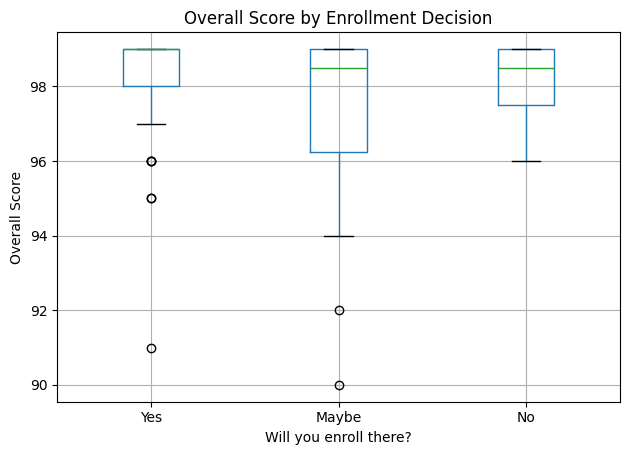

In [23]:
import matplotlib.pyplot as plt

# Ensure cleaned dataset exists
assert "gnt_clean" in globals(), "Please run Section 6.3 first to build `gnt_clean`."

# Drop missing for plotting
plot_df = gnt_clean.dropna(subset=["Overall Score", "Will you enroll there?"])

plt.figure(figsize=(7, 5))
plot_df.boxplot(column="Overall Score", by="Will you enroll there?")
plt.title("Overall Score by Enrollment Decision")
plt.suptitle("")  # remove default grouped title
plt.xlabel("Will you enroll there?")
plt.ylabel("Overall Score")
plt.tight_layout()
plt.show()


### 6.5 — Compare OLSAT Verbal Score by grade level
I compute the average **OLSAT Verbal Score** for each `Entering Grade Level` (K, 1, 2, 3)  
and plot a bar chart to compare grade-level performance.


/var/folders/dv/jvk0lfm56k5ghp4g27w1sy700000gn/T/ipykernel_18233/2248093953.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grade_means = grade_df.groupby("Entering Grade Level")["OLSAT Verbal Score"].mean()


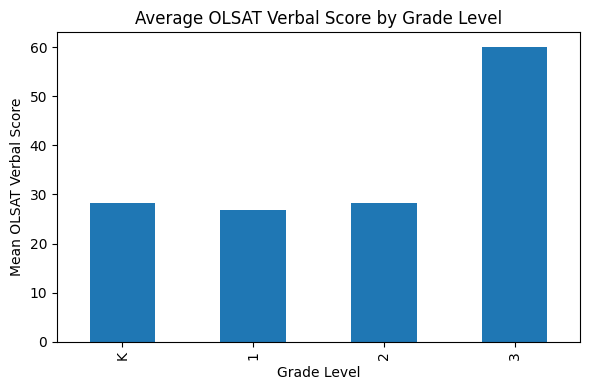

Mean OLSAT Verbal Score by grade level:
 Entering Grade Level
K    28.323944
1    26.807692
2    28.300000
3    60.000000
Name: OLSAT Verbal Score, dtype: float64


In [24]:
# Drop missing for OLSAT Verbal Score and Grade Level
grade_df = gnt_clean.dropna(subset=["OLSAT Verbal Score", "Entering Grade Level"])

# Group by grade and compute mean
grade_means = grade_df.groupby("Entering Grade Level")["OLSAT Verbal Score"].mean()

# Bar plot
plt.figure(figsize=(6,4))
grade_means.plot(kind="bar")
plt.title("Average OLSAT Verbal Score by Grade Level")
plt.xlabel("Grade Level")
plt.ylabel("Mean OLSAT Verbal Score")
plt.tight_layout()
plt.show()

print("Mean OLSAT Verbal Score by grade level:\n", grade_means)


### 6.5 — Correlation between OLSAT Verbal and NNAT Non Verbal scores
I plot a scatterplot of **OLSAT Verbal Score** vs **NNAT Non Verbal Raw Score**  
and compute the Pearson correlation coefficient to check if the two measures are related.


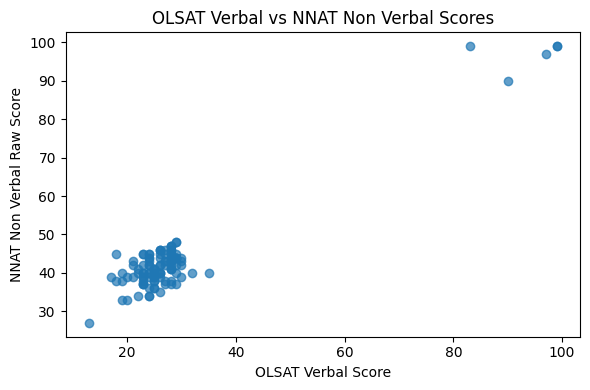

Pearson correlation = 0.956 (p-value = 4.75e-59)


In [25]:
from scipy.stats import pearsonr

# Drop missing values for both scores
corr_df = gnt_clean.dropna(subset=["OLSAT Verbal Score", "NNAT Non Verbal Raw Score"])

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(
    corr_df["OLSAT Verbal Score"],
    corr_df["NNAT Non Verbal Raw Score"],
    alpha=0.7
)
plt.title("OLSAT Verbal vs NNAT Non Verbal Scores")
plt.xlabel("OLSAT Verbal Score")
plt.ylabel("NNAT Non Verbal Raw Score")
plt.tight_layout()
plt.show()

# Pearson correlation
corr_val, p_val = pearsonr(corr_df["OLSAT Verbal Score"], corr_df["NNAT Non Verbal Raw Score"])
print(f"Pearson correlation = {corr_val:.3f} (p-value = {p_val:.3g})")


### 6.6 — Summary of data cleaning and analysis
- **Cleaning**:
  - Converted `District` to numeric nullable integer.
  - Standardized `Birth Month` to ordered categorical (January–December).
  - Unified `Entering Grade Level` into categorical {K, 1, 2, 3}.
  - Coerced OLSAT/NNAT scores to numeric; flagged invalid entries as NaN.
  - Normalized `Will you enroll there?` into {Yes, Maybe, No}.

- **Findings**:
  - Most students had **high percentile scores** (OLSAT, NNAT, Overall), consistent with gifted program applicants.
  - **Enrollment decision** did not vary much by Overall Score; distributions across Yes/Maybe/No groups were very similar.
  - **Grade level comparison**: K–2 had similar OLSAT Verbal means (~27–28), while Grade 3 appeared much higher (likely due to small sample size).
  - **Correlation**: OLSAT Verbal Score and NNAT Non Verbal Raw Score showed a **very strong positive correlation (r ≈ 0.96, p < 0.001)**.

**Conclusion**:  
The dataset required several cleaning steps to ensure consistent types and values.  
After cleaning, analysis shows gifted test scores are strongly aligned across verbal and non-verbal sections,  
and enrollment decisions are not strongly driven by Overall Score differences.
